# **Pedestrian Counting System Dataset - Exploratory Data Analysis**

> ***Brijit Benny (225155645)***


<br>

*References:*
1. https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-counts-per-hour

2. https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-sensor-locations

3. streets_spatial.gpkg from PO files

<br>

This notebook explores the City of Melbourne Pedestrian Counting System hourly counts together with the sensor locations dataset. At this stage, the aim is to understand what information is available, check the quality and coverage of the data, and see whether it could be useful for later before-and-after streetscape intervention analysis.

## Loading the datasets

I used the hourly pedestrian counts as the main dataset and the sensor locations dataset as supporting information. The location data is useful because it provides sensor descriptions, coordinates, installation dates and other details that are not fully available from the count data alone.

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
counts = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour.csv")
locations = pd.read_csv("pedestrian-counting-system-sensor-locations.csv")
counts.head()


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,9220260801,9,2026-08-01,2,3,9,12,Col700_T,"-37.81982992, 144.95102555"
1,132220260801,132,2026-08-01,2,17,10,27,King335_T,"-37.81267639, 144.95386444"
2,161020260801,161,2026-08-01,0,1,6,7,BirArt1109_T,"-37.81851276, 144.97131336"
3,184320260801,184,2026-08-01,3,10,36,46,Eli124_T,"-37.81512416, 144.96371988"
4,4320260801,4,2026-08-01,3,33,82,115,Swa123_T,"-37.81487988, 144.9660878"


In [171]:
locations.head()

,location_id,sensor_description,sensor_name,installation_date,note,location_type,status,direction_1,direction_2,latitude,longitude,location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


## 1. Pedestrian counts - initial data checks

I first checked the structure of the hourly counts dataset, including its size, columns, missing values, duplicates, date range and number of sensors. This helps identify any obvious data quality issues before using the counts for further analysis.



In [172]:
counts.shape

(1612636, 9)

In [173]:
# Check the dataset structure and basic summary
counts.info()
counts.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1612636 entries, 0 to 1612635
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   id               1612636 non-null  int64 
 1   location_id      1612636 non-null  int64 
 2   sensing_date     1612636 non-null  object
 3   hourday          1612636 non-null  int64 
 4   direction_1      1612636 non-null  int64 
 5   direction_2      1612636 non-null  int64 
 6   pedestriancount  1612636 non-null  int64 
 7   sensor_name      1586935 non-null  object
 8   location         1586935 non-null  object
dtypes: int64(6), object(3)
memory usage: 110.7+ MB


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
count,1.612636e+06,1.612636e+06,1612636,1.612636e+06,1.612636e+06,1.612636e+06,1.612636e+06,1586935,1586935
unique,NaN,NaN,730,NaN,NaN,NaN,NaN,97,100
top,NaN,NaN,2025-10-25,NaN,NaN,NaN,NaN,FliS_T,"-37.81101524, 144.96429485"
freq,NaN,NaN,2358,NaN,NaN,NaN,NaN,34878,17498
mean,4.919977e+11,7.575750e+01,NaN,1.174928e+01,1.956571e+02,1.982326e+02,3.938898e+02,NaN,NaN
std,5.437375e+11,5.453907e+01,NaN,6.794017e+00,3.056780e+02,3.105468e+02,5.858893e+02,NaN,NaN
min,1.020241e+09,1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN
25%,6.662025e+10,3.100000e+01,NaN,6.000000e+00,1.800000e+01,1.800000e+01,3.800000e+01,NaN,NaN
50%,2.117203e+11,6.200000e+01,NaN,1.200000e+01,7.800000e+01,7.700000e+01,1.610000e+02,NaN,NaN
75%,7.511203e+11,1.300000e+02,NaN,1.800000e+01,2.340000e+02,2.390000e+02,4.900000e+02,NaN,NaN


In [174]:
counts.duplicated().sum()

np.int64(0)

In [175]:
# Check whether the same sensor has more than one record for the same date and hour
duplicate_sensor_hours = counts.duplicated(
    subset=["location_id", "sensing_date", "hourday"]
).sum()

print("Duplicate sensor-hour records:", duplicate_sensor_hours)

Duplicate sensor-hour records: 0


No complete duplicate rows were found. I also checked duplicates using sensor ID, date and hour, as each sensor should normally have one record for each hour. No duplicate sensor-hour records were found either.

In [176]:
counts.isnull().sum()

,0
id,0
location_id,0
sensing_date,0
hourday,0
direction_1,0
direction_2,0
pedestriancount,0
sensor_name,25701
location,25701


The main fields needed for pedestrian analysis, including the total count, directional counts, sensor ID, date and hour, do not have missing values. However, sensor_name and location are missing for 25,701 records. I checked the sensor IDs later to understand why these location details are missing.

In [177]:
# Convert the date column
counts["sensing_date"] = pd.to_datetime(counts["sensing_date"])

# Check the available time period
counts["sensing_date"].agg(["min", "max"])

,sensing_date
min,2024-08-02
max,2026-08-01


In [178]:
counts["location_id"].nunique()

103

The current file covers approximately two years, from 2 August 2024 to 1 August 2026. This limits the interventions that can be assessed using this file, as a useful before-and-after comparison would require enough observations on both sides of the intervention date. The count file contains 1,612,636 hourly records from 103 sensor IDs.

## 2. Sensor locations - initial data checks

I then explored the sensor locations dataset to understand what supporting information is available for each sensor and whether it can be linked reliably with the pedestrian counts.

In [179]:
locations.shape

(134, 12)

In [180]:
locations.info()
locations.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         134 non-null    int64  
 1   sensor_description  134 non-null    object 
 2   sensor_name         134 non-null    object 
 3   installation_date   133 non-null    object 
 4   note                38 non-null     object 
 5   location_type       134 non-null    object 
 6   status              134 non-null    object 
 7   direction_1         100 non-null    object 
 8   direction_2         100 non-null    object 
 9   latitude            134 non-null    float64
 10  longitude           134 non-null    float64
 11  location            134 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 12.7+ KB


,location_id,sensor_description,sensor_name,installation_date,note,location_type,status,direction_1,direction_2,latitude,longitude,location
count,134.000000,134,134,133,38,134,134,100,100,134.000000,134.000000,134
unique,NaN,133,131,79,24,2,1,2,2,NaN,NaN,134
top,NaN,Birrarung Marr East - Batman Ave Bridge Entry,Lat526_T,2023-10-23,"Pushbox Upgrade, 20/07/2023",Outdoor,A,North,South,NaN,NaN,"-37.81101524, 144.96429485"
freq,NaN,2,2,12,5,100,134,53,53,NaN,NaN,1
mean,90.753731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-37.812225,144.960510,NaN
std,54.535418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007225,0.009814,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-37.825910,144.928606,NaN
25%,45.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-37.817280,144.956532,NaN
50%,86.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-37.813390,144.961900,NaN
75%,139.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-37.807702,144.965806,NaN


In [181]:
print("Duplicate rows:", locations.duplicated().sum())
print("Duplicate location IDs:", locations["location_id"].duplicated().sum())

Duplicate rows: 0
Duplicate location IDs: 0


In [182]:
locations.isnull().sum()

,0
location_id,0
sensor_description,0
sensor_name,0
installation_date,1
note,96
location_type,0
status,0
direction_1,34
direction_2,34
latitude,0


Most missing values in the sensor locations dataset are in the note field. There are also 34 sensors without direction labels, but these sensors do not appear in the current pedestrian counts file. I kept the note column because the available notes include information about sensor replacements, relocations and upgrades, which may be important when analysing a sensor over time.

In [183]:
locations["installation_date"] = pd.to_datetime(
    locations["installation_date"],
    errors="coerce"
)

Since the two datasets need to be merged using location_id, I checked whether the sensor IDs are consistent between them.

In [184]:
locations["location_id"].nunique()

134

In [185]:
set(counts["location_id"]) - set(locations["location_id"])

{28, 65, 78}

In [186]:
set(locations["location_id"]) - set(counts["location_id"])

{80,
 81,
 82,
 83,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 99,
 102,
 103,
 104,
 105,
 106,
 116,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 158,
 159,
 160}

Most count sensors can be matched with the location metadata, but sensor IDs 28, 65 and 78 appear in the counts file without a corresponding record in the sensor locations file. There are also sensor IDs in the locations file that do not appear in the current count file. This means the two files do not have complete one-to-one sensor coverage.

In [187]:
counts[
    counts["location_id"].isin([28, 65, 78])
]["location_id"].value_counts()

,count
location_id,
78,12922
28,11198
65,1581


The three unmatched sensor IDs account for the 25,701 records with missing sensor name/location information in the counts dataset. This suggests the missing location information is related to unmatched sensor metadata rather than missing pedestrian counts.

## 3. Merging pedestrian counts with sensor information

The two datasets both contain direction fields, but they represent different information. In the pedestrian counts dataset, the direction fields contain the number of pedestrians travelling in each direction. In the sensor locations dataset, they contain the direction names such as North, South, East or West. I renamed these columns before merging so their meaning is clear.

I then merged the datasets using location_id. I used a left join because the hourly pedestrian counts are the main data being analysed, so I wanted to keep all count records even where matching sensor information was unavailable.

In [188]:
# Renaming the direction fields so their meaning is clear before merging
counts = counts.rename(columns={
    "direction_1": "direction_1_count",
    "direction_2": "direction_2_count"
})

locations = locations.rename(columns={
    "direction_1": "direction_1_name",
    "direction_2": "direction_2_name"
})

df = counts.merge(
    locations,
    on="location_id",
    how="left",
    suffixes=("_count", "_sensor")
)

df.head()

,id,location_id,sensing_date,hourday,direction_1_count,direction_2_count,pedestriancount,sensor_name_count,location_count,sensor_description,sensor_name_sensor,installation_date,note,location_type,status,direction_1_name,direction_2_name,latitude,longitude,location_sensor
0,9220260801,9,2026-08-01,2,3,9,12,Col700_T,"-37.81982992, 144.95102555",Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
1,132220260801,132,2026-08-01,2,17,10,27,King335_T,"-37.81267639, 144.95386444",I-Hub Corner of King Street and Latrobe Street...,King335_T,2023-09-25,NaN,Outdoor,A,North,South,-37.812676,144.953864,"-37.81267639, 144.95386444"
2,161020260801,161,2026-08-01,0,1,6,7,BirArt1109_T,"-37.81851276, 144.97131336",Birrarung Marr - COM - Pole 1109,BirArt1109_T,2024-06-04,NaN,Outdoor,A,East,West,-37.818513,144.971313,"-37.81851276, 144.97131336"
3,184320260801,184,2026-08-01,3,10,36,46,Eli124_T,"-37.81512416, 144.96371988",124 Elizabeth Street,Eli124_T,2025-06-28,NaN,Outdoor,A,North,South,-37.815124,144.963720,"-37.81512416, 144.96371988"
4,4320260801,4,2026-08-01,3,33,82,115,Swa123_T,"-37.81487988, 144.9660878",Town Hall (West),Swa123_T,2009-03-23,NaN,Outdoor,A,North,South,-37.814880,144.966088,"-37.81487988, 144.9660878"


In [189]:
# cleaning
df = df.drop(columns=[
    "sensor_name_count",
    "location_count"
])

df = df.rename(columns={
    "sensor_name_sensor": "sensor_name",
    "location_sensor": "location"
})

df.head()

,id,location_id,sensing_date,hourday,direction_1_count,direction_2_count,pedestriancount,sensor_description,sensor_name,installation_date,note,location_type,status,direction_1_name,direction_2_name,latitude,longitude,location
0,9220260801,9,2026-08-01,2,3,9,12,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
1,132220260801,132,2026-08-01,2,17,10,27,I-Hub Corner of King Street and Latrobe Street...,King335_T,2023-09-25,NaN,Outdoor,A,North,South,-37.812676,144.953864,"-37.81267639, 144.95386444"
2,161020260801,161,2026-08-01,0,1,6,7,Birrarung Marr - COM - Pole 1109,BirArt1109_T,2024-06-04,NaN,Outdoor,A,East,West,-37.818513,144.971313,"-37.81851276, 144.97131336"
3,184320260801,184,2026-08-01,3,10,36,46,124 Elizabeth Street,Eli124_T,2025-06-28,NaN,Outdoor,A,North,South,-37.815124,144.963720,"-37.81512416, 144.96371988"
4,4320260801,4,2026-08-01,3,33,82,115,Town Hall (West),Swa123_T,2009-03-23,NaN,Outdoor,A,North,South,-37.814880,144.966088,"-37.81487988, 144.9660878"


In [190]:
print("Merged dataset shape:", df.shape)

print("\nMissing values after merge:")
print(df.isnull().sum())

Merged dataset shape: (1612636, 18)

Missing values after merge:
id                          0
location_id                 0
sensing_date                0
hourday                     0
direction_1_count           0
direction_2_count           0
pedestriancount             0
sensor_description      25701
sensor_name             25701
installation_date       42257
note                  1067621
location_type           25701
status                  25701
direction_1_name        25701
direction_2_name        25701
latitude                25701
longitude               25701
location                25701
dtype: int64


In [191]:
print(
    "Records without a matching sensor description:",
    df["sensor_description"].isna().sum()
)

Records without a matching sensor description: 25701


After merging, I checked the missing values again to see whether any pedestrian count records could not be matched with sensor information. Some records do not have a sensor description because a small number of sensor IDs in the counts data are not available in the sensor locations dataset.

In [192]:
df.columns

Index(['id', 'location_id', 'sensing_date', 'hourday', 'direction_1_count',
       'direction_2_count', 'pedestriancount', 'sensor_description',
       'sensor_name', 'installation_date', 'note', 'location_type', 'status',
       'direction_1_name', 'direction_2_name', 'latitude', 'longitude',
       'location'],
      dtype='object')

In [193]:
direction_check = (
    df["direction_1_count"] + df["direction_2_count"]
    == df["pedestriancount"]
)

print(
    "Percentage where Direction 1 + Direction 2 equals total count:",
    round(direction_check.mean() * 100, 2),
    "%"
)

Percentage where Direction 1 + Direction 2 equals total count: 100.0 %


I also checked whether the two directional pedestrian counts add up to the overall pedestrian count. They match for all records in the current dataset. This confirms that the directional fields can potentially be used later to analyse pedestrian movement in more detail.

## 4. Basic pedestrian activity patterns

As an initial check of the pedestrian counts, I compared the average hourly count across sensor locations. This gives a basic idea of which sensors capture the highest pedestrian activity, although high activity alone does not mean that a sensor is suitable for intervention analysis.

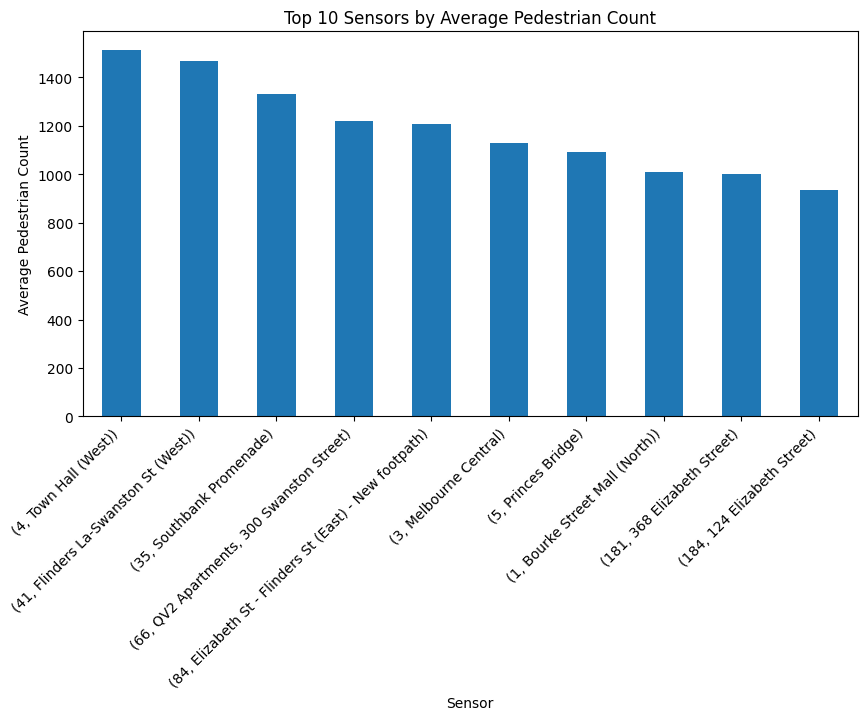

In [194]:
top = (
    df.groupby(["location_id", "sensor_description"])["pedestriancount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Sensors by Average Pedestrian Count")
plt.xlabel("Sensor")
plt.ylabel("Average Pedestrian Count")
plt.xticks(rotation=45, ha="right")

plt.show()

Town Hall (West) has the highest average hourly pedestrian count in the current dataset, followed by Flinders Lane-Swanston Street (West) and Southbank Promenade. These locations represent high pedestrian activity, but the result mainly describes overall usage and does not by itself show the effect of a streetscape intervention.

I also created a sensor-level summary showing the average pedestrian count, variation in hourly counts and number of days with recorded data. The number of recorded days provides an initial indication of whether all sensors have similar historical coverage.

In [195]:
summary = (
    df.groupby(["location_id", "sensor_description"])
    .agg(
        average_count=("pedestriancount", "mean"),
        count_std=("pedestriancount", "std"),
        days_recorded=("sensing_date", "nunique")
    )
    .reset_index()
)
summary.head()

,location_id,sensor_description,average_count,count_std,days_recorded
0,1,Bourke Street Mall (North),1009.477201,1044.353914,491
1,2,Bourke Street Mall (South),624.300635,671.933544,730
2,3,Melbourne Central,1128.652360,967.742851,730
3,4,Town Hall (West),1513.534275,1323.142626,728
4,5,Princes Bridge,1091.360574,987.658633,730


## 5. Hourly pattern at high-activity sensors

I compared the hourly pattern for the five sensors with the highest average counts to see whether pedestrian activity follows similar or different daily patterns across busy locations.

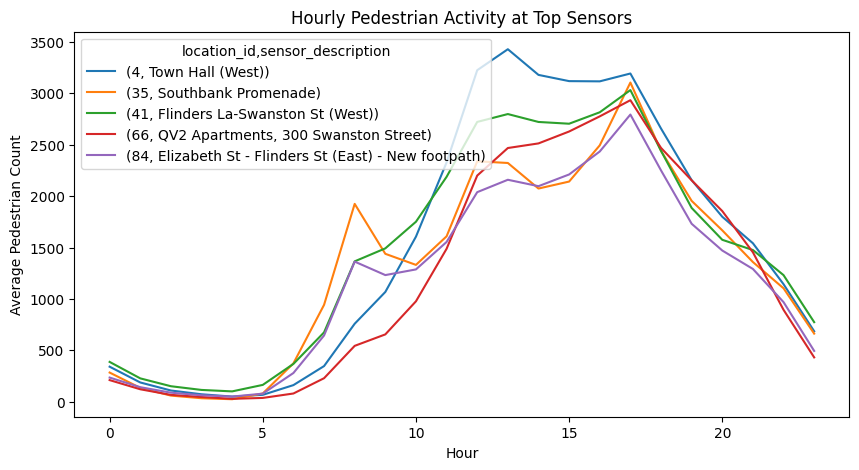

In [196]:
# Find the 5 busiest sensors
top5_sensors = (
    df.groupby(["location_id", "sensor_description"])["pedestriancount"]
    .mean()
    .nlargest(5)
    .reset_index()
)

top5_ids = top5_sensors["location_id"].tolist()

# Average pedestrian activity by hour
hourly = (
    df[df["location_id"].isin(top5_ids)]
    .groupby(["hourday", "location_id", "sensor_description"])["pedestriancount"]
    .mean()
    .unstack(["location_id", "sensor_description"])
)

hourly.plot(figsize=(10, 5))

plt.title("Hourly Pedestrian Activity at Top Sensors")
plt.xlabel("Hour")
plt.ylabel("Average Pedestrian Count")

plt.show()

The busiest sensors generally show low activity overnight and much higher activity during the daytime. Most of the selected locations peak around 5 pm, while Town Hall (West) has its highest average count earlier in the afternoon. This shows that the dataset captures clear time-of-day patterns, which would need to be controlled for when comparing pedestrian activity before and after an intervention.

## 6. Monthly patterns at high-activity sensors

I also checked monthly average hourly counts for the busiest sensors to see how pedestrian activity changes over time. This helps identify whether normal month-to-month variation could affect a future before-and-after comparison.

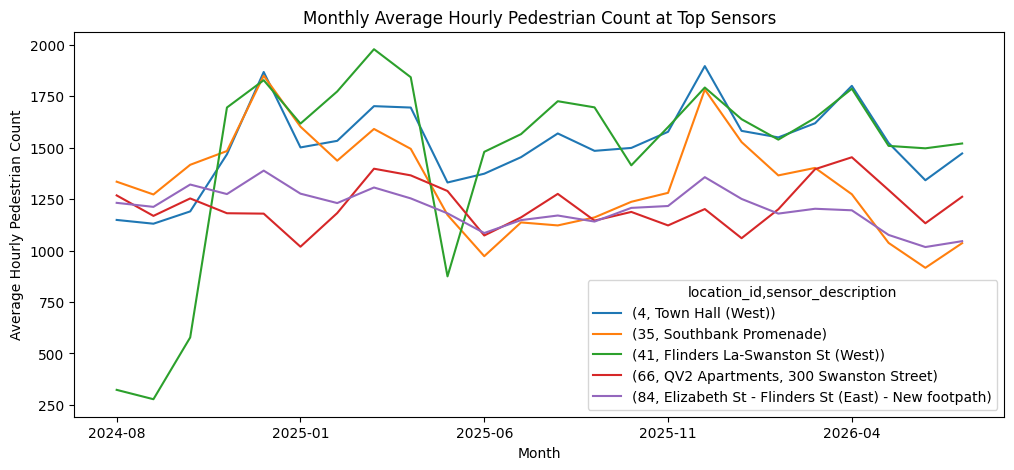

In [197]:
df["Month"] = df["sensing_date"].dt.to_period("M")

top5 = (
    df.groupby(["location_id", "sensor_description"])["pedestriancount"]
    .mean()
    .nlargest(5)
    .reset_index()
)

top5_ids = top5["location_id"].tolist()

monthly = (
    df[df["location_id"].isin(top5_ids)]
    .groupby(["Month", "location_id", "sensor_description"])["pedestriancount"]
    .mean()
    .unstack(["location_id", "sensor_description"])
)

monthly.index = monthly.index.astype(str)
monthly = monthly[monthly.index != "2026-08"]

monthly.plot(figsize=(12, 5))

plt.title("Monthly Average Hourly Pedestrian Count at Top Sensors")
plt.xlabel("Month")
plt.ylabel("Average Hourly Pedestrian Count")

plt.show()

Pedestrian activity changes across months, and some sensors show noticeable changes over time. These differences could be related to seasonal patterns, data coverage or changes at the sensor, so the monthly pattern should be checked before making a simple before-and-after comparison.

In [198]:
df[[
    "location_id",
    "sensor_description",
    "direction_1_name",
    "direction_2_name",
    "direction_1_count",
    "direction_2_count",
    "pedestriancount"
]].head(10)

,location_id,sensor_description,direction_1_name,direction_2_name,direction_1_count,direction_2_count,pedestriancount
0,9,Southern Cross Station,East,West,3,9,12
1,132,I-Hub Corner of King Street and Latrobe Street...,North,South,17,10,27
2,161,Birrarung Marr - COM - Pole 1109,East,West,1,6,7
3,184,124 Elizabeth Street,North,South,10,36,46
4,4,Town Hall (West),North,South,33,82,115
5,47,Melbourne Central-Elizabeth St (East),North,South,165,185,350
6,117,114 Flinders Street Car Park Footpath,East,West,58,24,82
7,30,Lonsdale St (South),East,West,52,46,98
8,167,I-Hub 526 La Trobe Street (Crossing),North,South,2,3,5
9,87,Errol St (West),North,South,1,2,3


In [199]:
import geopandas as gpd
streets = gpd.read_file("streets_spatial.gpkg")
streets.head()

,street_name,street_segment_id,suburb,postcode,lga,treatment_or_control,intervention_type,cbd,metro,regional,geometry
0,KEILOR ROAD,211.0,Essendon,3040,Moonee Valley (C),control,control,0.0,1.0,0.0,"LINESTRING (2491114.443 2417873.878, 2491077.3..."
1,KEILOR ROAD,212.0,Niddrie,3042,Moonee Valley (C),control,control,0.0,1.0,0.0,"LINESTRING (2490510.786 2418174.272, 2490453.5..."
2,VICTORIA AVENUE,224.0,Albert Park,3206,Port Phillip (C),control,control,0.0,1.0,0.0,"LINESTRING (2495452.168 2405934.307, 2495484.1..."
3,MALING ROAD,269.0,Canterbury,3126,Boroondara (C),control,control,0.0,1.0,0.0,"LINESTRING (2507070.632 2408393.017, 2507081.7..."
4,STEPHENSONS ROAD,300.0,Mount Waverley,3149,Monash (C),control,control,0.0,1.0,0.0,"LINESTRING (2511307.487 2402518.689, 2511325.0..."


In [200]:
streets[
    (streets["street_name"] == "SWANSTON STREET") &
    (streets["suburb"] == "Carlton")
][[
    "street_name",
    "suburb",
    "treatment_or_control",
    "intervention_type"
]].drop_duplicates()

,street_name,suburb,treatment_or_control,intervention_type
279,SWANSTON STREET,Carlton,treatment,protected bike lane


## 7. Swanston Street Pedestrian Count Analysis

I selected Swanston Street in Carlton for a closer street-level analysis. It is one of the treatment streets in the project and there are four pedestrian sensors around this section with North and South count data. I used these sensors to see whether the pedestrian count pattern is similar across the street and whether it changes between the morning and evening.

### 7.1 Swanston Street Sensors

In [201]:
# Find all sensors on Swanston Street
swanston_sensors = locations[
    locations["sensor_description"]
    .str.contains("Swanston", case=False, na=False)
][[
    "location_id",
    "sensor_description",
    "installation_date",
    "status",
    "direction_1_name",
    "direction_2_name",
    "latitude",
    "longitude"
]]

swanston_sensors

,location_id,sensor_description,installation_date,status,direction_1_name,direction_2_name,latitude,longitude
7,19,Chinatown-Swanston St (North),2013-09-02,A,East,West,-37.812372,144.965507
11,41,Flinders La-Swanston St (West),2017-06-29,A,North,South,-37.816686,144.966897
12,43,Monash Rd-Swanston St (West),2015-04-15,A,North,South,-37.798445,144.964118
13,44,Tin Alley-Swanston St (West),2015-04-15,A,North,South,-37.796987,144.964413
21,54,Lincoln-Swanston (West),2018-06-26,A,North,South,-37.804024,144.963084
48,160,"City Baths, 420 Swanston Street - Main Entry",2024-06-04,A,NaN,NaN,-37.806995,144.963062
62,45,Little Collins St-Swanston St (East),2017-06-29,A,North,South,-37.814141,144.966094
68,66,"QV2 Apartments, 300 Swanston Street",2020-04-06,A,North,South,-37.810578,144.964443
107,42,Grattan St-Swanston St (West),NaT,A,North,South,-37.800086,144.963864
133,187,RMIT Building 22 - 330 Swanston Street,2025-10-18,A,East,West,-37.809426,144.963955


In [202]:
# Swanston Street sensors in Carlton
swanston_ids = [54, 42, 43, 44]

swanston_data = df[
    df["location_id"].isin(swanston_ids)
].copy()

swanston_data[[
    "location_id",
    "sensor_description",
    "direction_1_name",
    "direction_2_name"
]].drop_duplicates()

,location_id,sensor_description,direction_1_name,direction_2_name
21,43,Monash Rd-Swanston St (West),North,South
33,44,Tin Alley-Swanston St (West),North,South
90,42,Grattan St-Swanston St (West),North,South
508,54,Lincoln-Swanston (West),North,South


In [203]:
swanston_data.groupby("sensor_description")["sensing_date"].agg(
    ["min", "max", "nunique"]
)

,min,max,nunique
sensor_description,,,
Grattan St-Swanston St (West),2024-08-02,2026-08-01,705
Lincoln-Swanston (West),2024-08-04,2026-07-31,727
Monash Rd-Swanston St (West),2024-08-02,2026-08-01,715
Tin Alley-Swanston St (West),2024-08-02,2026-08-01,730


All four sensors cover most of the two-year period, so I kept them for the comparison.

In [204]:
# Renaming
swanston_data = swanston_data.rename(columns={
    "direction_1_count": "north_count",
    "direction_2_count": "south_count"
})


### 7.2 Morning and Evening Pattern

I compared the morning period from 7–11 am with the evening period from 5–9 pm to see whether the pedestrian counts were moving in the same direction at each location.

In [205]:
morning = swanston_data[swanston_data["hourday"].between(7, 11)]
evening = swanston_data[swanston_data["hourday"].between(17, 21)]

morning = morning.groupby("sensor_description")[["north_count", "south_count"]].mean()
evening = evening.groupby("sensor_description")[["north_count", "south_count"]].mean()

comparison = pd.DataFrame()

comparison["Morning North %"] = (
    morning["north_count"] / (morning["north_count"] + morning["south_count"]) * 100
)

comparison["Evening North %"] = (
    evening["north_count"] / (evening["north_count"] + evening["south_count"]) * 100
)

comparison.round(2)

,Morning North %,Evening North %
sensor_description,,
Grattan St-Swanston St (West),54.92,38.54
Lincoln-Swanston (West),63.29,41.76
Monash Rd-Swanston St (West),59.50,39.96
Tin Alley-Swanston St (West),42.69,52.37


Grattan, Lincoln and Monash showed a similar pattern. A higher share of pedestrians were moving North in the morning, while Southbound movement became dominant in the evening. Tin Alley was different and showed the opposite pattern. This shows that the way pedestrian counts are split by direction is not exactly the same across the whole Swanston Street section.

### 7.3 Weekday and Weekend Pattern

I then separated weekdays and weekends to check whether the morning-to-evening pattern was the same across the week.

In [206]:
swanston_data["day_type"] = "Weekday"
swanston_data.loc[
    swanston_data["sensing_date"].dt.dayofweek >= 5,
    "day_type"
] = "Weekend"

swanston_data["time"] = ""
swanston_data.loc[swanston_data["hourday"].between(7, 11), "time"] = "Morning"
swanston_data.loc[swanston_data["hourday"].between(17, 21), "time"] = "Evening"

# Keep only morning and evening
day_flow = swanston_data[swanston_data["time"] != ""]

day_flow = day_flow.groupby(
    ["sensor_description", "day_type", "time"]
)[["north_count", "south_count"]].mean()

day_flow["north_percent"] = (
    day_flow["north_count"] /
    (day_flow["north_count"] + day_flow["south_count"]) * 100
)

day_flow[["north_percent"]].round(2)

north_percent
sensor_description            day_type time                  
Grattan St-Swanston St (West) Weekday  Evening          37.69
                                       Morning          55.23
                              Weekend  Evening          44.01
                                       Morning          51.31
Lincoln-Swanston (West)       Weekday  Evening          39.64
                                       Morning          65.66
                              Weekend  Evening          49.51
                                       Morning          50.68
Monash Rd-Swanston St (West)  Weekday  Evening          39.13
                                       Morning          60.31
                              Weekend  Evening          45.99
                                       Morning          53.28
Tin Alley-Swanston St (West)  Weekday  Evening          52.96
                                       Morning          42.41
                              Weekend  Evening          49.18
                                       Morning          44.18

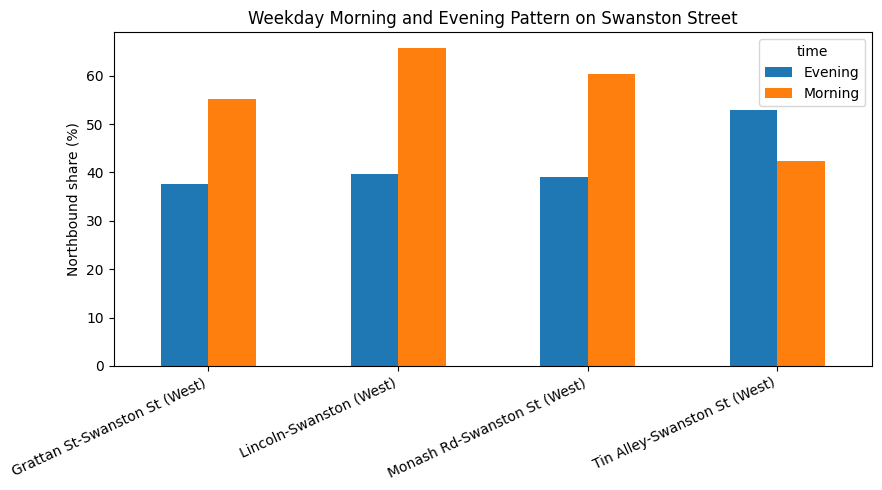

In [207]:
weekday_plot = day_flow.reset_index()
weekday_plot = weekday_plot[weekday_plot["day_type"] == "Weekday"]

weekday_plot = weekday_plot.pivot(
    index="sensor_description",
    columns="time",
    values="north_percent"
)

weekday_plot.plot(kind="bar", figsize=(9, 5))

plt.title("Weekday Morning and Evening Pattern on Swanston Street")
plt.xlabel("")
plt.ylabel("Northbound share (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

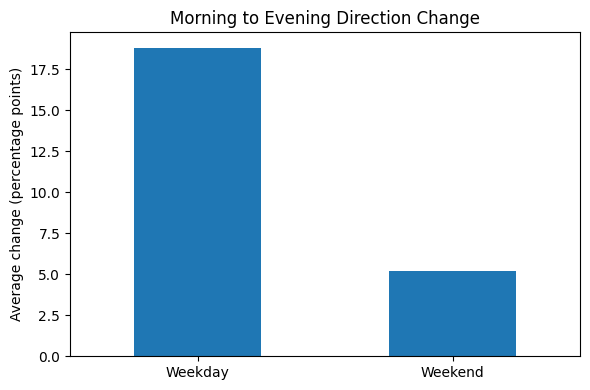

In [208]:
# Compare the morning to evening change
change = day_flow.reset_index().pivot(
    index=["sensor_description", "day_type"],
    columns="time",
    values="north_percent"
)

change["difference"] = abs(change["Evening"] - change["Morning"])

average_change = change.groupby("day_type")["difference"].mean()

average_change.plot(kind="bar", figsize=(6, 4))

plt.title("Morning to Evening Direction Change")
plt.ylabel("Average change (percentage points)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## What I Found

The results showed a clear morning-to-evening pattern at three of the four Swanston Street sensors. Grattan, Lincoln and Monash had a higher Northbound share in the morning, but the pedestrian counts shifted more towards Southbound movement in the evening. Lincoln showed the biggest weekday change, followed by Monash and Grattan.

Tin Alley was different from the other three locations. It had more Southbound activity in the morning and slightly more Northbound activity in the evening. This shows that the pedestrian count pattern can change even between sensors along the same street.

The change was also much stronger on weekdays. Across the four sensors, the average morning-to-evening directional change was about 18.8 percentage points on weekdays, compared with about 5.2 percentage points on weekends. So the stronger pattern seems to be mainly happening during weekdays, while weekends are more balanced.

## How This Helps the Project

This analysis helped me understand that the pedestrian count dataset can show more than just which locations are busy. Looking at the North and South counts showed that pedestrian activity changes depending on both the location of the sensor and the time of day.

This is useful for the project because combining all sensors on a street into one total count could hide some of these differences. On Swanston Street, three sensors followed a similar weekday pattern, while Tin Alley behaved differently. This means the location of the sensor should be considered when using pedestrian counts for street-level analysis.

This does not show whether the protected bike lane caused the pattern, since I have not done a before-and-after comparison. However, it shows that the dataset has useful detail for understanding pedestrian activity at a street level and could support a more targeted intervention analysis later.

Overall, the dataset appears suitable for further pedestrian analysis, particularly for Melbourne locations with established sensors. The main count fields are complete and consistent, but sensor metadata and time coverage need to be checked before using individual locations. The Swanston Street analysis also showed that pedestrian patterns can vary within the same street, which means individual sensor locations should be considered carefully in later intervention analysis.